<a href="https://colab.research.google.com/github/Anonymous-Chris/recursive-llm-degradation-research/blob/domain-evaluation/src/notebooks/01_data_pipeline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Install Packages

In [2]:
import torch

print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

CUDA available: True
GPU: Tesla T4


In [2]:
import os

print("Current directory:")
print(os.getcwd())

print("\nFiles/folders:")
!ls -lah

Current directory:
/content

Files/folders:
total 16K
drwxr-xr-x 1 root root 4.0K Sep  4 13:32 .
drwxr-xr-x 1 root root 4.0K Sep 17 15:47 ..
drwxr-xr-x 4 root root 4.0K Sep  4 13:32 .config
drwxr-xr-x 1 root root 4.0K Sep  4 13:32 sample_data


In [ ]:
# Install packages
# %pip install -r ../../requirements.txt

In [ ]:
# Install scispacy model for classification (inside .venv)
# pip install https://s3-us-west-2.amazonaws.com/ai2-s2-scispacy/releases/v0.5.4/en_core_sci_sm-0.5.4.tar.gz

In [ ]:
import datasets
import pandas as pd
import numpy as np
import spacy
import scispacy
import torch
import peft
import accelerate
import bitsandbytes as bnb
from transformers import pipeline

print("datasets:", datasets.__version__)
print("pandas:", pd.__version__)
print("numpy:", np.__version__)
print("spacy:", spacy.__version__)
print("scispacy:", scispacy.__version__)
print("torch:", torch.__version__)
print("peft:", peft.__version__)
print("accelerate:", accelerate.__version__)
print("bitsandbytes:", bnb.__version__)

/Users/chris/Desktop/Research/recursive-llm-degradation-research/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


datasets: 5.0.1
pandas: 3.0.5
numpy: 1.26.4
spacy: 3.7.5
scispacy: 0.6.2
torch: 2.14.0
peft: 0.21.0
accelerate: 1.15.0
bitsandbytes: 0.50.2


In [ ]:
from datasets import load_dataset

unlabeled_data = load_dataset("qiaojin/PubMedQA", "pqa_unlabeled", split="train")
labeled_data = load_dataset("qiaojin/PubMedQA", "pqa_labeled", split="train")

In [ ]:
print(unlabeled_data)
print(unlabeled_data[0])
print(labeled_data)
print(labeled_data[0])

Dataset({
    features: ['pubid', 'question', 'context', 'long_answer'],
    num_rows: 61249
})
{'pubid': 14499029, 'question': 'Is naturopathy as effective as conventional therapy for treatment of menopausal symptoms?', 'context': {'contexts': ['Although the use of alternative medicine in the United States is increasing, no published studies have documented the effectiveness of naturopathy for treatment of menopausal symptoms compared to women receiving conventional therapy in the clinical setting.', 'To compare naturopathic therapy with conventional medical therapy for treatment of selected menopausal symptoms.', 'A retrospective cohort study, using abstracted data from medical charts.', 'One natural medicine and six conventional medical clinics at Community Health Centers of King County, Washington, from November 1, 1996, through July 31, 1998.', 'Women aged 40 years of age or more with a diagnosis of menopausal symptoms documented by a naturopathic or conventional physician.', 'Imp

In [ ]:
# Before using the labeled set as your gold evaluation set, check whether its questions/pubids overlap with the unlabeled pool. If there is overlap, we must exclude those rows from your training pool.
labeled_ids = set(labeled_data["pubid"])
unlabeled_ids = set(unlabeled_data["pubid"])

overlap = labeled_ids.intersection(unlabeled_ids)

print("Overlap:", len(overlap))
gold_eval_set = labeled_data
# Remove any gold-eval examples from the unlabeled training pool
if len(overlap) > 0:
    unlabeled_data = unlabeled_data.filter(
        lambda row: row["pubid"] not in overlap
    )
print(f"Gold eval: {len(gold_eval_set)}")

Overlap: 0
Gold eval: 1000


In [ ]:
# Create human training pool
SEED = 42

unlabeled_data_shuffled = unlabeled_data.shuffle(seed=SEED)

G0_BASE_SIZE = 500
ANCHOR_POOL_SIZE = 500

g0_human_train = unlabeled_data_shuffled.select(range(G0_BASE_SIZE))

human_anchor_pool = unlabeled_data_shuffled.select(
    range(G0_BASE_SIZE, G0_BASE_SIZE + ANCHOR_POOL_SIZE)
)

print(f"G0 train: {len(g0_human_train)}")
print(f"Anchor pool: {len(human_anchor_pool)}")
print(f"Gold eval: {len(gold_eval_set)}")

G0 train: 500
Anchor pool: 500
Gold eval: 1000


In [ ]:
print(g0_human_train[0])

{'pubid': 22949290, 'question': 'Unipolar mania: a distinct entity or characteristic of manic preponderance?', 'context': {'contexts': ['It has been reported that fewer patients with unipolar mania respond to lithium prophylaxis as do those with classical bipolar disorder. This study aimed to determine if the difference to response to lithium is related to unipolar mania or to a high preponderance of mania during the course of bipolarity.', 'The study included bipolar-I patients (according to DSM-IV criteria) that had a ≥ 2-year history of either lithium or valproate prophylaxis as monotherapy. The response rate in the patients with unipolar mania and classical bipolar disorder were compared. Then, the response rate to lithium in all the patients with a manic episode rate<50% and>50%, and<80% and>80% during their course were compared. Finally, the above comparisons were repeated, excluding the patients with unipolar mania.', 'The study included 121 bipolar-I patients (34 unipolar mania

In [ ]:
# Prompt formatting
def format_pubmed_qa(row):
    ctx = row["context"]
    if isinstance(ctx, dict) and "contexts" in ctx:
        context_str = " ".join(ctx["contexts"])
    elif isinstance(ctx, list):
        context_str = " ".join(ctx)
    else:
        context_str = str(ctx)
    return {
        "text": (
            f"### Question:\n{row['question']}\n\n"
            f"### Context:\n{context_str}\n\n"
            f"### Long Answer:\n{row['long_answer']}"
        )
    }

g0_formatted = g0_human_train.map(format_pubmed_qa)
print("Number of formatted rows:", len(g0_formatted))
print("\n--- SAMPLE ---\n")
print(g0_formatted[0]["text"])

Map: 100%|██████████| 500/500 [00:00<00:00, 7862.98 examples/s]

Number of formatted rows: 500

--- SAMPLE ---

### Question:
Unipolar mania: a distinct entity or characteristic of manic preponderance?

### Context:
It has been reported that fewer patients with unipolar mania respond to lithium prophylaxis as do those with classical bipolar disorder. This study aimed to determine if the difference to response to lithium is related to unipolar mania or to a high preponderance of mania during the course of bipolarity. The study included bipolar-I patients (according to DSM-IV criteria) that had a ≥ 2-year history of either lithium or valproate prophylaxis as monotherapy. The response rate in the patients with unipolar mania and classical bipolar disorder were compared. Then, the response rate to lithium in all the patients with a manic episode rate<50% and>50%, and<80% and>80% during their course were compared. Finally, the above comparisons were repeated, excluding the patients with unipolar mania. The study included 121 bipolar-I patients (34 unipol

In [ ]:
print(g0_formatted[0])

{'pubid': 22949290, 'question': 'Unipolar mania: a distinct entity or characteristic of manic preponderance?', 'context': {'contexts': ['It has been reported that fewer patients with unipolar mania respond to lithium prophylaxis as do those with classical bipolar disorder. This study aimed to determine if the difference to response to lithium is related to unipolar mania or to a high preponderance of mania during the course of bipolarity.', 'The study included bipolar-I patients (according to DSM-IV criteria) that had a ≥ 2-year history of either lithium or valproate prophylaxis as monotherapy. The response rate in the patients with unipolar mania and classical bipolar disorder were compared. Then, the response rate to lithium in all the patients with a manic episode rate<50% and>50%, and<80% and>80% during their course were compared. Finally, the above comparisons were repeated, excluding the patients with unipolar mania.', 'The study included 121 bipolar-I patients (34 unipolar mania

Load PubMedBERT BC5CDR NER

In [ ]:
# Try new classifier
pubmed_ner_pipeline = pipeline(
    "token-classification",
    model="HFpf/pubmedbert-bc5cdr-ner",
    aggregation_strategy="simple"
)

print("PubMedBERT BC5CDR NER loaded!")

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 6124.06it/s]


PubMedBERT BC5CDR NER loaded!


In [ ]:
# B- (Begin) — marks the first token of an entity span.
# I- (Inside) — marks any subsequent token that continues the same entity span.
# O (Outside) — the token isn't part of any entity at all.
LABEL_MAP = {
    "LABEL_0": "O",
    "LABEL_1": "B-Chemical",
    "LABEL_2": "B-Disease",
    "LABEL_3": "I-Disease",
    "LABEL_4": "I-Chemical"
}

def extract_pubmed_entities(text):
    raw_entities = pubmed_ner_pipeline(text)

    entities = []
    current = None

    for entity in raw_entities:
        label = LABEL_MAP[entity["entity_group"]]

        # Outside any entity
        if label == "O":
            if current is not None:
                entities.append(current)
                current = None
            continue

        prefix, entity_type = label.split("-", 1)

        start = entity["start"]
        end = entity["end"]
        score = float(entity["score"])

        # Beginning of a new entity
        if prefix == "B":
            if current is not None:
                entities.append(current)

            current = {
                "entity": text[start:end],
                "type": entity_type,
                "start": start,
                "end": end,
                "scores": [score]
            }

        # Continuation of current entity
        elif prefix == "I":
            if current is not None and current["type"] == entity_type:
                current["entity"] = text[current["start"]:end]
                current["end"] = end
                current["scores"].append(score)

    if current is not None:
        entities.append(current)

    # Average scores across entity pieces
    for entity in entities:
        entity["score"] = (
            sum(entity["scores"]) / len(entity["scores"])
        )
        del entity["scores"]

    return entities

In [ ]:
text = (
    "Patients with bipolar disorder were treated "
    "with lithium and valproate."
)
print(g0_formatted[0]["text"])

entities = extract_pubmed_entities(text)

for entity in entities:
    print(
        f"{entity['type']:10s} | "
        f"{entity['entity']:25s} | "
        f"score={entity['score']:.3f}"
    )

### Question:
Unipolar mania: a distinct entity or characteristic of manic preponderance?

### Context:
It has been reported that fewer patients with unipolar mania respond to lithium prophylaxis as do those with classical bipolar disorder. This study aimed to determine if the difference to response to lithium is related to unipolar mania or to a high preponderance of mania during the course of bipolarity. The study included bipolar-I patients (according to DSM-IV criteria) that had a ≥ 2-year history of either lithium or valproate prophylaxis as monotherapy. The response rate in the patients with unipolar mania and classical bipolar disorder were compared. Then, the response rate to lithium in all the patients with a manic episode rate<50% and>50%, and<80% and>80% during their course were compared. Finally, the above comparisons were repeated, excluding the patients with unipolar mania. The study included 121 bipolar-I patients (34 unipolar mania and 87 classical bipolar disorder). Th

In [ ]:
for i in range(10):
    text = g0_formatted[i]["long_answer"]
    print(text)
    print(f"\n{'=' * 80}")
    print(f"Example {i}")
    print(f"{'=' * 80}")

    entities = extract_pubmed_entities(text)

    for entity in entities:
        print(
            f"{entity['type']:10s} | "
            f"{entity['entity']:35s} | "
            f"score={entity['score']:.3f}"
        )

Fewer patients with unipolar mania responded to lithium prophylaxis than those with classical bipolar disorder, which appeared to be related to unipolar mania, rather than to a high manic predominance during the disease course. On the other hand, response to valproate prophylaxis was similar in the unipolar mania and classical bipolar disorder groups.

Example 0
Disease    | unipolar mania                      | score=0.985
Chemical   | lithium                             | score=1.000
Disease    | bipolar disorder                    | score=0.999
Disease    | unipolar mania                      | score=0.978
Disease    | manic                               | score=0.661
Chemical   | valproate                           | score=1.000
Disease    | unipolar mania                      | score=0.988
Disease    | bipolar disorder                    | score=0.999
Our findings demonstrate socioeconomic inequalities in AMI incidence in migrant groups and suggest a convergence towards the Dutch 

In [ ]:
from transformers import AutoTokenizer
import numpy as np

MODEL_NAME = "Qwen/Qwen2.5-0.5B"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

token_lengths = []

for row in g0_formatted:
    token_ids = tokenizer(
        row["text"],
        add_special_tokens=True
    )["input_ids"]

    token_lengths.append(len(token_ids))

In [ ]:
print("Min:", np.min(token_lengths))
print("Mean:", np.mean(token_lengths))
print("Median:", np.median(token_lengths))
print("90th percentile:", np.percentile(token_lengths, 90))
print("95th percentile:", np.percentile(token_lengths, 95))
print("99th percentile:", np.percentile(token_lengths, 99))
print("Max:", np.max(token_lengths))

Min: 157
Mean: 407.664
Median: 395.5
90th percentile: 531.0
95th percentile: 602.1999999999998
99th percentile: 801.0799999999999
Max: 1126


In [ ]:
for limit in [512, 768, 1024, 1536, 2048]:
    count = sum(length > limit for length in token_lengths)

    print(
        f"> {limit}: "
        f"{count} examples "
        f"({count / len(token_lengths) * 100:.2f}%)"
    )

> 512: 64 examples (12.80%)
> 768: 7 examples (1.40%)
> 1024: 2 examples (0.40%)
> 1536: 0 examples (0.00%)
> 2048: 0 examples (0.00%)


In [ ]:
# Use 768 as 99th percentile is  733
long_indices = [
    i for i, length in enumerate(token_lengths)
    if length > 1024
]

print("Examples over 768:", len(long_indices))

for i in long_indices[:5]:
    print("=" * 80)
    print("Index:", i)
    print("Tokens:", token_lengths[i])
    print()
    print(g0_formatted[i]["text"][:1500])
    print()

Examples over 768: 2
Index: 45
Tokens: 1103

### Question:
Is Pes Cavus Alignment Associated With Lisfranc Injuries of the Foot?

### Context:
Lisfranc (tarsometatarsal joint) injuries are relatively rare, accounting for less than 1% of all fractures, and as many as 20% of subtle Lisfranc injuries are missed at the initial patient presentation. An undiagnosed Lisfranc injury can have devastating consequences to the patient. Therefore, any factor that can raise a clinician's index of suspicion to make this diagnosis is potentially important. The cavus foot has been associated with various maladies of the lower extremity, but to our knowledge, it has not been reported to be associated with Lisfranc injury.QUESTIONS/ Do patients who experience a low-energy Lisfranc injury have greater talar head coverage and a greater talo-first metatarsal angle than control subjects? A retrospective, case-control study was conducted from September 2011 to December 2014 to identify patients diagnosed and 

Tokenization

Only use long_answer for loss not quesiton and context

In [ ]:
MAX_LENGTH = 1024

def tokenize_function(row):
    context = row["context"]

    if isinstance(context, dict) and "contexts" in context:
        context_text = " ".join(context["contexts"])
    elif isinstance(context, list):
        context_text = " ".join(context)
    else:
        context_text = str(context)

    prompt = (
        f"### Question:\n{row['question']}\n\n"
        f"### Context:\n{context_text}\n\n"
        f"### Long Answer:\n"
    )

    answer = row["long_answer"]

    prompt_tokens = tokenizer(
        prompt,
        add_special_tokens=False
    )["input_ids"]

    answer_tokens = tokenizer(
        answer,
        add_special_tokens=False
    )["input_ids"]

    input_ids = prompt_tokens + answer_tokens
    # -100 means ignore token when calculating training loss
    # Positive numbers are actual token IDs
    labels = (
        [-100] * len(prompt_tokens)
        + answer_tokens
    )

    input_ids = input_ids[:MAX_LENGTH]
    labels = labels[:MAX_LENGTH]

    attention_mask = [1] * len(input_ids)

    return {
        "input_ids": input_ids,
        "attention_mask": attention_mask,
        "labels": labels
    }

In [ ]:
g0_tokenized = g0_formatted.map(
    tokenize_function,
    batched=False
)

Map: 100%|██████████| 500/500 [00:00<00:00, 1043.12 examples/s]


In [ ]:
row = g0_tokenized[0]

print("input_ids length:", len(row["input_ids"]))
print("labels length:", len(row["labels"]))
print("attention_mask length:", len(row["attention_mask"]))

input_ids length: 402
labels length: 402
attention_mask length: 402


In [ ]:
row = g0_tokenized[0]

ignored = row["labels"].count(-100)

trained = sum(
    label != -100
    for label in row["labels"]
)

print("Ignored prompt tokens (Question + Context):", ignored)
print("Answer tokens used for loss (Answer):", trained)

Ignored prompt tokens (Question + Context): 327
Answer tokens used for loss (Answer): 75


In [ ]:
answer_token_ids = [
    label
    for label in row["labels"]
    if label != -100
]

decoded_answer = tokenizer.decode(
    answer_token_ids,
    skip_special_tokens=True
)

print(decoded_answer)

Fewer patients with unipolar mania responded to lithium prophylaxis than those with classical bipolar disorder, which appeared to be related to unipolar mania, rather than to a high manic predominance during the disease course. On the other hand, response to valproate prophylaxis was similar in the unipolar mania and classical bipolar disorder groups.


In [ ]:
print(g0_formatted[0]["long_answer"])

Fewer patients with unipolar mania responded to lithium prophylaxis than those with classical bipolar disorder, which appeared to be related to unipolar mania, rather than to a high manic predominance during the disease course. On the other hand, response to valproate prophylaxis was similar in the unipolar mania and classical bipolar disorder groups.


QLoRA Setup

In [ ]:
import torch
import transformers
import peft
import accelerate
import bitsandbytes as bnb

print("torch:", torch.__version__)
print("transformers:", transformers.__version__)
print("peft:", peft.__version__)
print("accelerate:", accelerate.__version__)
print("bitsandbytes:", bnb.__version__)

print()
print("MPS available:", torch.backends.mps.is_available())

torch: 2.14.0
transformers: 5.17.0
peft: 0.21.0
accelerate: 1.15.0
bitsandbytes: 0.50.2

MPS available: True


In [ ]:
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print("Using:", device)


Using: mps


In [ ]:
import torch
from transformers import AutoModelForCausalLM, BitsAndBytesConfig

# Config might change for CUDA if GPU supports BF16
# Ex: bnb_4bit_compute_dtype=torch.bfloat16
'''
Load Qwen using 4-bit weights
        ↓
Use NF4 representation
        ↓
Do calculations in FP16
        ↓
Apply extra compression to quantization metadata
'''
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_use_double_quant=True,
)

model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    quantization_config=bnb_config,
    device_map="auto"
)

print("Model loaded successfully.")
print("Model device:", next(model.parameters()).device)

Loading weights: 100%|██████████| 290/290 [00:03<00:00, 94.23it/s] 


Model loaded successfully.
Model device: mps:0


Prepare model for QLoRA training

In [ ]:
from peft import prepare_model_for_kbit_training

model = prepare_model_for_kbit_training(model)

print("Model prepared for k-bit training.")

Model prepared for k-bit training.


In [ ]:
from peft import LoraConfig

lora_config = LoraConfig(
    r=16,
    lora_alpha=32,
    lora_dropout=0.05,
    target_modules=[
        "q_proj",
        "k_proj",
        "v_proj",
        "o_proj",
        "gate_proj",
        "up_proj",
        "down_proj"
    ],
    bias="none",
    task_type="CAUSAL_LM"
)

In [ ]:
from peft import get_peft_model

model = get_peft_model(
    model,
    lora_config
)

model.print_trainable_parameters()

trainable params: 8,798,208 || all params: 502,830,976 || trainable%: 1.7497


In [ ]:
row = g0_tokenized[0]

print("First 40 labels:")
print(row["labels"][:40])

print("\nLast 40 labels:")
print(row["labels"][-40:])
print(len(row["labels"]))

First 40 labels:
[-100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100]

Last 40 labels:
[1091, 311, 264, 1550, 69122, 33964, 681, 2337, 279, 8457, 3308, 13, 1913, 279, 1008, 1424, 11, 2033, 311, 1044, 776, 349, 39234, 3923, 7184, 572, 4428, 304, 279, 650, 573, 7417, 883, 685, 323, 28824, 64819, 19267, 5203, 13]
402


In [ ]:
def custom_data_collator(features):
    max_length = max(len(f["input_ids"]) for f in features)

    input_ids = []
    attention_masks = []
    labels = []

    for feature in features:
        pad_length = max_length - len(feature["input_ids"])

        input_ids.append(
            feature["input_ids"] + [tokenizer.pad_token_id] * pad_length
        )

        attention_masks.append(
            feature["attention_mask"] + [0] * pad_length
        )

        labels.append(
            feature["labels"] + [-100] * pad_length
        )

    return {
        "input_ids": torch.tensor(input_ids, dtype=torch.long),
        "attention_mask": torch.tensor(attention_masks, dtype=torch.long),
        "labels": torch.tensor(labels, dtype=torch.long),
    }

In [ ]:
from transformers import TrainingArguments

training_args = TrainingArguments(
    output_dir=f"../models/{MODEL_NAME}-g0",
    num_train_epochs=1,
    per_device_train_batch_size=1,
    gradient_accumulation_steps=8,
    learning_rate=2e-4,
    logging_steps=10,
    save_strategy="steps",
    save_steps=250,
    save_total_limit=2,
    bf16=True,
    gradient_checkpointing=True,
    torch_empty_cache_steps=50,
    report_to="none",
)

In [ ]:
from transformers import Trainer

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=g0_tokenized,
    data_collator=custom_data_collator
)

In [ ]:
print("Trainer created successfully.")
print("Training examples:", len(g0_tokenized))
print("Device:", trainer.args.device)

Trainer created successfully.
Training examples: 500
Device: mps


In [ ]:
train_dataloader = trainer.get_train_dataloader()

batch = next(iter(train_dataloader))

print(batch.keys())
print("input_ids shape:", batch["input_ids"].shape)
print("attention_mask shape:", batch["attention_mask"].shape)
print("labels shape:", batch["labels"].shape)

dict_keys(['input_ids', 'attention_mask', 'labels'])
input_ids shape: torch.Size([1, 416])
attention_mask shape: torch.Size([1, 416])
labels shape: torch.Size([1, 416])


/Users/chris/Desktop/Research/recursive-llm-degradation-research/.venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


In [ ]:
print("input_ids device:", batch["input_ids"].device)
print("Model device:", next(model.parameters()).device)

input_ids device: mps:0
Model device: mps:0


In [ ]:
print("First 30 input IDs:")
print(batch["input_ids"][0][:30])

print("\nFirst 30 labels:")
print(batch["labels"][0][:30])

First 30 input IDs:
tensor([14374, 15846,   510, 21468,  1356,  2851,   278, 62759, 32587,  8063,
        23460, 46347, 98547,  7269,  9387, 17984,  7813,   304,  6835,   448,
        46347, 18906, 81989,  5866,   315,   220,    19,    13,    16,    12],
       device='mps:0')

First 30 labels:
tensor([-100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100,
        -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100,
        -100, -100, -100, -100, -100, -100], device='mps:0')


In [ ]:
padding_count = (batch["labels"] == -100).sum().item()

print("Ignored/padded label positions:", padding_count)

Ignored/padded label positions: 317


In [ ]:
trainer.train()
model.save_pretrained(F"../models/{MODEL_NAME}-g0")
tokenizer.save_pretrained(F"../models/{MODEL_NAME}-g0")

Step,Training Loss
10,2.412893
20,2.336673
30,2.453428
40,2.376309
50,2.308429
60,2.317807


('./models/qwen2.5-0.5b-g0/tokenizer_config.json',
 './models/qwen2.5-0.5b-g0/chat_template.jinja',
 './models/qwen2.5-0.5b-g0/tokenizer.json')

In [ ]:
# smoke_train = g0_tokenized.select(range(100))

# print("Smoke-test examples:", len(smoke_train))

In [ ]:
# trainer.train()
# model.save_pretrained("../models/qwen2.5-0.5b-g0")
# tokenizer.save_pretrained("../models/qwen2.5-0.5b-g0")

In [ ]:
# from transformers import Trainer

# smoke_trainer = Trainer(
#     model=model,
#     args=training_args,
#     train_dataset=smoke_train,
#     data_collator=custom_data_collator
# )

In [ ]:
# smoke_trainer.train()

In [ ]:
# Testing the model
import torch

from transformers import (
    AutoModelForCausalLM,
    AutoTokenizer,
    BitsAndBytesConfig,
)

from peft import PeftModel
ADAPTER_PATH = f"../models/{MODEL_NAME}-g0"

tokenizer = AutoTokenizer.from_pretrained(
    ADAPTER_PATH
)

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_use_double_quant=True,
)
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print("Using:", device)

base_model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    quantization_config=bnb_config,
    device_map=device
)

model = PeftModel.from_pretrained(
    base_model,
    ADAPTER_PATH
)

model.eval()
print("Model loaded.")
print("Device:", next(model.parameters()).device)

for i in range(3):
    row = gold_eval_set[i]

    context = row["context"]

    if isinstance(context, dict) and "contexts" in context:
        context_text = " ".join(context["contexts"])
    elif isinstance(context, list):
        context_text = " ".join(context)
    else:
        context_text = str(context)

    prompt = (
        f"### Question:\n{row['question']}\n\n"
        f"### Context:\n{context_text}\n\n"
        f"### Long Answer:\n"
    )

    inputs = tokenizer(
        prompt,
        return_tensors="pt",
        truncation=True,
        max_length=1024
    )

    inputs = {
        key: value.to(model.device)
        for key, value in inputs.items()
    }

    with torch.no_grad():
        output_ids = model.generate(
            **inputs,
            max_new_tokens=120,
            do_sample=False,
            repetition_penalty=1.15,
            no_repeat_ngram_size=3,
            pad_token_id=tokenizer.pad_token_id,
            eos_token_id=tokenizer.eos_token_id
        )

    prompt_length = inputs["input_ids"].shape[1]

    generated_ids = output_ids[0][prompt_length:]

    generated_answer = tokenizer.decode(
        generated_ids,
        skip_special_tokens=True
    )

    print("\n" + "=" * 100)
    print(f"EXAMPLE {i}")
    print("=" * 100)

    print("\nQUESTION:")
    print(row["question"])

    print("\nGENERATED ANSWER:")
    print(generated_answer)

    print("\nHUMAN ANSWER:")
    print(row["long_answer"])

Using: mps


Loading weights: 100%|██████████| 290/290 [00:03<00:00, 88.68it/s] 


Model loaded.
Device: mps:0

EXAMPLE 0

QUESTION:
Do mitochondria play a role in remodelling lace plant leaves during programmed cell death?

GENERATED ANSWER:
Mitochondria may be involved in the regulation of PPD in Aponothea madagassariensis by influencing the rate of PDC. These findings suggest that PCD can occur without the involvement of mitochondrion. Further studies should examine whether this process could be used as a tool for monitoring PCD or other developmental events in plants.
This work provides evidence suggesting that PCC does not require the participation of mitochondrii. It suggests that PDC involves multiple mechanisms, which include changes in mitochondrial function. Future research should focus on investigating how PDC affects the structure of the vascular

HUMAN ANSWER:
Results depicted mitochondrial dynamics in vivo as PCD progresses within the lace plant, and highlight the correlation of this organelle with other organelles during developmental PCD. To the best 

# Evaluation is doing from here


In [3]:
from google.colab import drive

drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
!find /content/drive -type d -name "Qwen2.5-0.5B-g0"

/content/drive/.shortcut-targets-by-id/1eQJTWimEKgHUoLDgs8cXZgM38VRJP20l/Qwen2.5-0.5B-g0
/content/drive/.Encrypted/.shortcut-targets-by-id/1eQJTWimEKgHUoLDgs8cXZgM38VRJP20l/Qwen2.5-0.5B-g0


In [5]:
G0_PATH = "/content/drive/.shortcut-targets-by-id/1eQJTWimEKgHUoLDgs8cXZgM38VRJP20l/Qwen2.5-0.5B-g0"

!ls -lah "$G0_PATH"

total 45M
drwx------ 4 root root 4.0K Sep 17 15:16 .
dr-x------ 3 root root 4.0K Sep 17 15:16 ..
-rw------- 1 root root 1.2K Sep 17 14:41 adapter_config.json
-rw------- 1 root root  34M Sep 17 14:41 adapter_model.safetensors
-rw------- 1 root root 2.4K Sep 17 14:41 chat_template.jinja
drwx------ 2 root root 4.0K Sep 17 15:16 checkpoint-2
-rw------- 1 root root 5.1K Sep 17 14:41 README.md
-rw------- 1 root root  697 Sep 17 14:41 tokenizer_config.json
-rw------- 1 root root  11M Sep 17 14:41 tokenizer.json


In [6]:
import json

G0_PATH = "/content/drive/.shortcut-targets-by-id/1eQJTWimEKgHUoLDgs8cXZgM38VRJP20l/Qwen2.5-0.5B-g0"

with open(f"{G0_PATH}/adapter_config.json", "r") as f:
    adapter_config = json.load(f)

print(json.dumps(adapter_config, indent=2))

{
  "alora_invocation_tokens": null,
  "alpha_pattern": {},
  "arrow_config": null,
  "auto_mapping": null,
  "base_model_name_or_path": "Qwen/Qwen2.5-0.5B",
  "bias": "none",
  "corda_config": null,
  "ensure_weight_tying": false,
  "eva_config": null,
  "exclude_modules": null,
  "fan_in_fan_out": false,
  "inference_mode": true,
  "init_lora_weights": true,
  "kasa_config": null,
  "layer_replication": null,
  "layers_pattern": null,
  "layers_to_transform": null,
  "loftq_config": {},
  "lora_alpha": 32,
  "lora_bias": false,
  "lora_dropout": 0.05,
  "lora_ga_config": null,
  "megatron_config": null,
  "megatron_core": "megatron.core",
  "modules_to_save": null,
  "monteclora_config": null,
  "peft_type": "LORA",
  "peft_version": "0.21.0",
  "qalora_group_size": 16,
  "r": 16,
  "rank_pattern": {},
  "revision": null,
  "target_modules": [
    "v_proj",
    "gate_proj",
    "down_proj",
    "up_proj",
    "o_proj",
    "q_proj",
    "k_proj"
  ],
  "target_parameters": null,
  "t

In [9]:
from datasets import load_dataset

labeled_data = load_dataset(
    "qiaojin/PubMedQA",
    "pqa_labeled",
    split="train"
)

gold_eval_set = labeled_data

print("Gold evaluation set loaded!")
print("Number of examples:", len(gold_eval_set))

README.md:   0%|          | 0.00/5.19k [00:00<?, ?B/s]

pqa_labeled/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 1.08MB            

pqa_labeled/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/1000 [00:00<?, ? examples/s]

Gold evaluation set loaded!
Number of examples: 1000


In [7]:
import torch
from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM,
    BitsAndBytesConfig
)
from peft import PeftModel

BASE_MODEL = "Qwen/Qwen2.5-0.5B"

G0_PATH = "/content/drive/.shortcut-targets-by-id/1eQJTWimEKgHUoLDgs8cXZgM38VRJP20l/Qwen2.5-0.5B-g0"

print("Loading tokenizer...")

tokenizer = AutoTokenizer.from_pretrained(G0_PATH)

if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

print("Loading base model...")

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_use_double_quant=True
)

base_model = AutoModelForCausalLM.from_pretrained(
    BASE_MODEL,
    quantization_config=bnb_config,
    device_map="auto"
)

print("Loading G0 LoRA adapter...")

g0_model = PeftModel.from_pretrained(
    base_model,
    G0_PATH
)

g0_model.eval()

print("G0 model loaded successfully!")

Loading tokenizer...
Loading base model...


model.safetensors: reconstructing file:   0%|          |  0.00B /  988MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/138 [00:00<?, ?B/s]

Loading G0 LoRA adapter...


/usr/local/lib/python3.13/dist-packages/peft/config.py:220: UserWarning: Unexpected keyword arguments ['kasa_config'] for class LoraConfig, these are ignored. This probably means that you're loading a configuration file that was saved using a higher version of the library and additional parameters have been introduced since. It is highly recommended to upgrade the PEFT version before continuing (e.g. by running `pip install -U peft`).
  warnings.warn(


G0 model loaded successfully!


In [10]:
# Test G0 generation on 3 examples

import torch

g0_model.eval()

for i in range(3):
    row = gold_eval_set[i]

    context = row["context"]

    if isinstance(context, dict) and "contexts" in context:
        context_text = " ".join(context["contexts"])
    elif isinstance(context, list):
        context_text = " ".join(context)
    else:
        context_text = str(context)

    prompt = (
        f"### Question:\n{row['question']}\n\n"
        f"### Context:\n{context_text}\n\n"
        f"### Long Answer:\n"
    )

    inputs = tokenizer(
        prompt,
        return_tensors="pt",
        truncation=True,
        max_length=1024
    )

    inputs = {k: v.to(g0_model.device) for k, v in inputs.items()}

    with torch.no_grad():
        output_ids = g0_model.generate(
            **inputs,
            max_new_tokens=120,
            do_sample=False,
            repetition_penalty=1.15,
            no_repeat_ngram_size=3,
            pad_token_id=tokenizer.pad_token_id,
            eos_token_id=tokenizer.eos_token_id
        )

    prompt_length = inputs["input_ids"].shape[1]

    generated_ids = output_ids[0][prompt_length:]

    generated_answer = tokenizer.decode(
        generated_ids,
        skip_special_tokens=True
    ).strip()

    print("=" * 80)
    print(f"Example {i + 1}")
    print("QUESTION:")
    print(row["question"])
    print("\nGOLD ANSWER:")
    print(row["long_answer"])
    print("\nG0 ANSWER:")
    print(generated_answer)

Example 1
QUESTION:
Do mitochondria play a role in remodelling lace plant leaves during programmed cell death?

GOLD ANSWER:
Results depicted mitochondrial dynamics in vivo as PCD progresses within the lace plant, and highlight the correlation of this organelle with other organelles during developmental PCD. To the best of our knowledge, this is the first report of mitochondria and chloroplasts moving on transvacuolar strands to form a ring structure surrounding the nucleus during developmental PCD. Also, for the first time, we have shown the feasibility for the use of CsA in a whole plant system. Overall, our findings implicate the mitochondria as playing a critical and early role in developmentally regulated PCD in the lace plant.

G0 ANSWER:
Mitochondria have long been known as important regulators of cellular function. They provide energy for many processes such as growth, division, and apoptosis. However, their roles in developmental events remain poorly understood. In this study,

In [14]:
print("Padding side:", tokenizer.padding_side)
print("Pad token:", tokenizer.pad_token)
print("Pad token ID:", tokenizer.pad_token_id)
print("EOS token ID:", tokenizer.eos_token_id)

Padding side: right
Pad token: <|endoftext|>
Pad token ID: 151643
EOS token ID: 151643


In [15]:
# Set left padding for batched generation
tokenizer.padding_side = "left"

print("Padding side:", tokenizer.padding_side)

Padding side: left


In [16]:
print("Padding side:", tokenizer.padding_side)

Padding side: left


In [17]:
# Batched G0 generation for all 1,000 evaluation examples

import torch
from tqdm.auto import tqdm

g0_model.eval()

BATCH_SIZE = 4
MAX_INPUT_LENGTH = 1024
MAX_NEW_TOKENS = 120

g0_predictions = []

for start in tqdm(
    range(0, len(gold_eval_set), BATCH_SIZE),
    desc="Generating G0 answers"
):

    # Get individual rows correctly from Hugging Face Dataset
    end = min(start + BATCH_SIZE, len(gold_eval_set))
    batch_rows = [gold_eval_set[i] for i in range(start, end)]

    prompts = []

    for row in batch_rows:

        context = row["context"]

        if isinstance(context, dict) and "contexts" in context:
            context_text = " ".join(context["contexts"])
        elif isinstance(context, list):
            context_text = " ".join(context)
        else:
            context_text = str(context)

        prompt = (
            f"### Question:\n{row['question']}\n\n"
            f"### Context:\n{context_text}\n\n"
            f"### Long Answer:\n"
        )

        prompts.append(prompt)

    # Tokenize the whole batch
    inputs = tokenizer(
        prompts,
        return_tensors="pt",
        padding=True,
        truncation=True,
        max_length=MAX_INPUT_LENGTH
    )

    inputs = {
        k: v.to(g0_model.device)
        for k, v in inputs.items()
    }

    # Generate answers
    with torch.no_grad():
        output_ids = g0_model.generate(
            **inputs,
            max_new_tokens=MAX_NEW_TOKENS,
            do_sample=False,
            repetition_penalty=1.15,
            no_repeat_ngram_size=3,
            pad_token_id=tokenizer.pad_token_id,
            eos_token_id=tokenizer.eos_token_id
        )

    # Decode each answer
    for j in range(len(batch_rows)):

        input_length = inputs["attention_mask"][j].sum().item()

        generated_ids = output_ids[j][input_length:]

        generated_answer = tokenizer.decode(
            generated_ids,
            skip_special_tokens=True
        ).strip()

        g0_predictions.append(generated_answer)


print("\nGeneration complete!")
print("Number of G0 predictions:", len(g0_predictions))

Generating G0 answers:   0%|          | 0/250 [00:00<?, ?it/s]


Generation complete!
Number of G0 predictions: 1000


In [18]:
import pandas as pd

# Create evaluation dataframe
g0_eval_df = pd.DataFrame({
    "pubid": [gold_eval_set[i]["pubid"] for i in range(len(gold_eval_set))],
    "question": [gold_eval_set[i]["question"] for i in range(len(gold_eval_set))],
    "context": [gold_eval_set[i]["context"] for i in range(len(gold_eval_set))],
    "gold_answer": [gold_eval_set[i]["long_answer"] for i in range(len(gold_eval_set))],
    "g0_answer": g0_predictions
})

print("Rows:", len(g0_eval_df))
print(g0_eval_df.head(2))

Rows: 1000
      pubid                                           question  \
0  21645374  Do mitochondria play a role in remodelling lac...   
1  16418930  Landolt C and snellen e acuity: differences in...   

                                             context  \
0  {'contexts': ['Programmed cell death (PCD) is ...   
1  {'contexts': ['Assessment of visual acuity dep...   

                                         gold_answer  \
0  Results depicted mitochondrial dynamics in viv...   
1  Using the charts described, there was only a s...   

                                           g0_answer  
0  Mitochondria have long been known as important...  
1  with only small differences between LR and SE....  


In [20]:
output_path = "/content/g0_predictions.csv"

g0_eval_df.to_csv(output_path, index=False)

print("Saved:", output_path)

Saved: /content/g0_predictions.csv


In [21]:
import os

print("File exists:", os.path.exists(output_path))
print("File size:", os.path.getsize(output_path) / (1024 * 1024), "MB")

File exists: True
File size: 3.062901496887207 MB


In [22]:
from google.colab import files

files.download("/content/g0_predictions.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [23]:
g0_eval_df

,pubid,question,context,gold_answer,g0_answer
0,21645374,Do mitochondria play a role in remodelling lac...,{'contexts': ['Programmed cell death (PCD) is ...,Results depicted mitochondrial dynamics in viv...,Mitochondria have long been known as important...
1,16418930,Landolt C and snellen e acuity: differences in...,{'contexts': ['Assessment of visual acuity dep...,"Using the charts described, there was only a s...",with only small differences between LR and SE....
2,9488747,"Syncope during bathing in infants, a pediatric...",{'contexts': ['Apparent life-threatening event...,"""Aquagenic maladies"" could be a pediatric form...",: seizure or gastroesophageal reflux but this ...
3,17208539,Are the long-term results of the transanal pul...,{'contexts': ['The transanal endorectal pull-t...,Our long-term study showed significantly bette...,"data controlling for age, and this showed that..."
4,10808977,Can tailored interventions increase mammograph...,{'contexts': ['Telephone counseling and tailor...,The effects of the intervention were most pron...,", compared to usual care, telephone counseling..."
...,...,...,...,...,...
995,8921484,Does gestational age misclassification explain...,"{'contexts': ['After 34 weeks gestation, summa...",Gestational age misclassification is an unlike...,### Question:\nDoes gestational age misclassif...
996,16564683,Is there any interest to perform ultrasonograp...,{'contexts': ['To evaluate the accuracy of ult...,Sonography has no place in the diagnosis of un...,escended testis?\n\n### Context:\nTo evaluate ...
997,23147106,Is peak concentration needed in therapeutic dr...,{'contexts': ['We analyzed the pharmacokinetic...,These results suggest little need to use peak ...,aphylococcus aureus pneumonia and evaluated th...
998,21550158,Can autologous platelet-rich plasma gel enhanc...,{'contexts': ['This investigation assesses the...,"The PRP group recorded reduced pain, swelling,...",significant.\n\n### Long Answer:\nThe results ...


In [25]:
# Load PubMedBERT BC5CDR NER

from transformers import pipeline

pubmed_ner_pipeline = pipeline(
    "token-classification",
    model="HFpf/pubmedbert-bc5cdr-ner",
    aggregation_strategy="simple",
    device=0   # T4 GPU
)

print("PubMedBERT BC5CDR NER loaded!")

config.json:   0%|          | 0.00/918 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  436MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/379 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/679k [00:00<?, ?B/s]

PubMedBERT BC5CDR NER loaded!


In [28]:
# Test PubMedBERT BC5CDR NER on 3 examples

print("NER pipeline exists:", "pubmed_ner_pipeline" in globals())

for i in range(3):
    gold_text = g0_eval_df.loc[i, "gold_answer"]
    g0_text = g0_eval_df.loc[i, "g0_answer"]

    gold_entities = pubmed_ner_pipeline(gold_text)
    g0_entities = pubmed_ner_pipeline(g0_text)

    print("=" * 80)
    print(f"Example {i + 1}")

    print("\nGOLD ENTITIES:")
    for entity in gold_entities:
        print(
            entity["word"],
            "->",
            entity["entity_group"],
            f"(score={entity['score']:.3f})"
        )

    print("\nG0 ENTITIES:")
    for entity in g0_entities:
        print(
            entity["word"],
            "->",
            entity["entity_group"],
            f"(score={entity['score']:.3f})"
        )

[transformers] You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


NER pipeline exists: True
Example 1

GOLD ENTITIES:
results depicted mitochondrial dynamics in vivo as pcd progresses within the lace plant, and highlight the correlation of this organelle with other organelles during developmental pcd. to the best of our knowledge, this is the first report of mitochondria and chloroplasts moving on transvacuolar strands to form a ring structure surrounding the nucleus during developmental pcd. also, for the first time, we have shown the feasibility for the use of -> LABEL_0 (score=0.992)
csa -> LABEL_1 (score=0.998)
in a whole plant system. overall, our findings implicate the mitochondria as playing a critical and early role in developmentally regulated pcd in the lace plant. -> LABEL_0 (score=0.997)

G0 ENTITIES:
mitochondria have long been known as important regulators of cellular function. they provide energy for many processes such as growth, division, and apoptosis. however, their roles in developmental events remain poorly understood. in this st

In [30]:
# Clean PubMedBERT BC5CDR entity extraction

LABEL_MAP = {
    "LABEL_0": ("O", None),
    "LABEL_1": ("B", "Chemical"),
    "LABEL_2": ("B", "Disease"),
    "LABEL_3": ("I", "Disease"),
    "LABEL_4": ("I", "Chemical"),
}


def extract_pubmed_entities(text):
    predictions = pubmed_ner_pipeline(text)

    entities = []

    for pred in predictions:

        # Your pipeline uses "entity_group"
        label = pred["entity_group"]

        if label not in LABEL_MAP:
            continue

        prefix, entity_type = LABEL_MAP[label]

        if entity_type is None:
            continue

        entities.append({
            "prefix": prefix,
            "type": entity_type,
            "start": pred["start"],
            "end": pred["end"],
            "score": float(pred["score"]),
        })

    # Sort by location
    entities.sort(key=lambda x: x["start"])

    # Merge B + I pieces
    merged = []

    for entity in entities:

        if entity["prefix"] == "B":

            merged.append({
                "text": text[entity["start"]:entity["end"]],
                "type": entity["type"],
                "start": entity["start"],
                "end": entity["end"],
                "score": entity["score"],
            })

        elif entity["prefix"] == "I":

            if (
                merged
                and merged[-1]["type"] == entity["type"]
                and entity["start"] <= merged[-1]["end"] + 2
            ):
                merged[-1]["end"] = entity["end"]

                merged[-1]["text"] = text[
                    merged[-1]["start"]:merged[-1]["end"]
                ]

                merged[-1]["score"] = (
                    merged[-1]["score"] + entity["score"]
                ) / 2

            else:
                # Handle an I-token without a preceding B-token
                merged.append({
                    "text": text[entity["start"]:entity["end"]],
                    "type": entity["type"],
                    "start": entity["start"],
                    "end": entity["end"],
                    "score": entity["score"],
                })

    return merged


print("Entity extraction function ready!")

Entity extraction function ready!


In [31]:
# Test the cleaned entity extraction

for i in range(3):

    gold_entities = extract_pubmed_entities(
        g0_eval_df.loc[i, "gold_answer"]
    )

    g0_entities = extract_pubmed_entities(
        g0_eval_df.loc[i, "g0_answer"]
    )

    print("=" * 80)
    print(f"Example {i + 1}")

    print("\nGOLD:")
    for e in gold_entities:
        print(
            f"{e['text']} -> {e['type']} "
            f"(score={e['score']:.3f})"
        )

    print("\nG0:")
    for e in g0_entities:
        print(
            f"{e['text']} -> {e['type']} "
            f"(score={e['score']:.3f})"
        )

Example 1

GOLD:
CsA -> Chemical (score=0.998)

G0:
Example 2

GOLD:
strabismus amblyopia -> Disease (score=0.983)

G0:
Example 3

GOLD:
Aquagenic maladies -> Disease (score=0.896)
aquagenic urticaria -> Disease (score=0.857)

G0:
seizure -> Disease (score=0.999)
gastroesophageal reflux -> Disease (score=0.999)
aqu -> Disease (score=0.635)
urticaria -> Disease (score=0.859)
dermographism -> Disease (score=0.974)
dermographism -> Disease (score=0.988)
histamine -> Chemical (score=0.999)
aqu -> Disease (score=0.749)
maladies -> Disease (score=0.902)
aquigenesis -> Disease (score=0.928)
skin lesions -> Disease (score=0.871)
dermatitis herpetiformis -> Disease (score=0.988)
pallor -> Disease (score=0.938)
hypoxia -> Disease (score=0.996)
irritability -> Disease (score=0.997)


In [33]:
# Recreate PubMedBERT NER with sliding-window support

pubmed_ner_pipeline = pipeline(
    "token-classification",
    model="HFpf/pubmedbert-bc5cdr-ner",
    aggregation_strategy="simple",
    device=0,
    stride=128
)

print("NER pipeline ready with sliding-window processing!")
print("Tokenizer fast:", pubmed_ner_pipeline.tokenizer.is_fast)
print("Model max length:", pubmed_ner_pipeline.tokenizer.model_max_length)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

NER pipeline ready with sliding-window processing!
Tokenizer fast: True
Model max length: 1000000000000000019884624838656


In [34]:
# Run PubMedBERT NER over all 1,000 Gold + 1,000 G0 answers

from tqdm.auto import tqdm

gold_texts = g0_eval_df["gold_answer"].fillna("").tolist()
g0_texts = g0_eval_df["g0_answer"].fillna("").tolist()

all_texts = gold_texts + g0_texts

print("Total texts:", len(all_texts))

all_predictions = []

BATCH_SIZE_NER = 8

for start in tqdm(
    range(0, len(all_texts), BATCH_SIZE_NER),
    desc="Running PubMedBERT NER"
):

    batch = all_texts[start:start + BATCH_SIZE_NER]

    batch_predictions = pubmed_ner_pipeline(
        batch,
        batch_size=BATCH_SIZE_NER
    )

    all_predictions.extend(batch_predictions)

print("\nNER complete!")
print("Prediction sets:", len(all_predictions))

Total texts: 2000


Running PubMedBERT NER:   0%|          | 0/250 [00:00<?, ?it/s]


NER complete!
Prediction sets: 2000


In [35]:
# Check the actual PubMedBERT sequence length

actual_max_length = pubmed_ner_pipeline.model.config.max_position_embeddings

print("Model max_position_embeddings:", actual_max_length)

# Set tokenizer to the model's actual limit
pubmed_ner_pipeline.tokenizer.model_max_length = actual_max_length

print("Tokenizer max length set to:", pubmed_ner_pipeline.tokenizer.model_max_length)

Model max_position_embeddings: 512
Tokenizer max length set to: 512


In [36]:
# Run NER on all 1,000 Gold + 1,000 G0 answers

from tqdm.auto import tqdm

gold_texts = g0_eval_df["gold_answer"].fillna("").tolist()
g0_texts = g0_eval_df["g0_answer"].fillna("").tolist()

all_texts = gold_texts + g0_texts

print("Total texts:", len(all_texts))

all_predictions = []

BATCH_SIZE_NER = 8

for start in tqdm(
    range(0, len(all_texts), BATCH_SIZE_NER),
    desc="Running PubMedBERT NER"
):

    batch = all_texts[start:start + BATCH_SIZE_NER]

    batch_predictions = pubmed_ner_pipeline(
        batch,
        batch_size=BATCH_SIZE_NER
    )

    all_predictions.extend(batch_predictions)

print("\nNER complete!")
print("Prediction sets:", len(all_predictions))

Total texts: 2000


Running PubMedBERT NER:   0%|          | 0/250 [00:00<?, ?it/s]


NER complete!
Prediction sets: 2000


In [37]:
# Split the 2,000 NER outputs into Gold and G0
# and merge B/I tokens into complete entities

gold_texts = g0_eval_df["gold_answer"].fillna("").tolist()
g0_texts = g0_eval_df["g0_answer"].fillna("").tolist()

gold_raw_predictions = all_predictions[:1000]
g0_raw_predictions = all_predictions[1000:]

print("Gold raw predictions:", len(gold_raw_predictions))
print("G0 raw predictions:", len(g0_raw_predictions))


# Process Gold entities
gold_entities_all = []

for text, predictions in tqdm(
    zip(gold_texts, gold_raw_predictions),
    total=1000,
    desc="Merging Gold entities"
):
    gold_entities_all.append(
        merge_pubmed_predictions(text, predictions)
    )


# Process G0 entities
g0_entities_all = []

for text, predictions in tqdm(
    zip(g0_texts, g0_raw_predictions),
    total=1000,
    desc="Merging G0 entities"
):
    g0_entities_all.append(
        merge_pubmed_predictions(text, predictions)
    )


print("\nEntity processing complete!")
print("Gold entity sets:", len(gold_entities_all))
print("G0 entity sets:", len(g0_entities_all))

Gold raw predictions: 1000
G0 raw predictions: 1000


Merging Gold entities:   0%|          | 0/1000 [00:00<?, ?it/s]

Merging G0 entities:   0%|          | 0/1000 [00:00<?, ?it/s]


Entity processing complete!
Gold entity sets: 1000
G0 entity sets: 1000


In [38]:
# Inspect the first 3 processed examples

for i in range(3):
    print("=" * 80)
    print(f"Example {i + 1}")

    print("\nGOLD:")
    for e in gold_entities_all[i]:
        print(f"{e['text']} -> {e['type']}")

    print("\nG0:")
    for e in g0_entities_all[i]:
        print(f"{e['text']} -> {e['type']}")

Example 1

GOLD:
CsA -> Chemical

G0:
Example 2

GOLD:
strabismus amblyopia -> Disease

G0:
Example 3

GOLD:
Aquagenic maladies -> Disease
aquagenic urticaria -> Disease

G0:
seizure -> Disease
gastroesophageal reflux -> Disease
aqu -> Disease
urticaria -> Disease
dermographism -> Disease
dermographism -> Disease
histamine -> Chemical
aqu -> Disease
maladies -> Disease
aquigenesis -> Disease
skin lesions -> Disease
dermatitis herpetiformis -> Disease
pallor -> Disease
hypoxia -> Disease
irritability -> Disease


In [39]:
# Clean NER results
# IMPORTANT:
# - Remove only exact duplicate spans caused by overlapping windows
# - Do NOT manually correct incorrect entity predictions

import re
import unicodedata


def normalize_entity_text(text):
    text = unicodedata.normalize("NFKC", str(text))
    text = text.replace("##", "")
    text = re.sub(r"\s+", " ", text)
    text = text.strip(" \t\n.,;:()[]{}\"'")
    return text.lower()


def deduplicate_entities(entities):

    cleaned = []
    seen = set()

    for entity in entities:

        normalized = normalize_entity_text(entity["text"])

        if not normalized:
            continue

        # Span-based deduplication.
        # Same text occurring at different positions is kept.
        key = (
            entity["type"],
            entity["start"],
            entity["end"],
            normalized
        )

        if key in seen:
            continue

        seen.add(key)

        cleaned.append({
            "text": entity["text"].strip(),
            "normalized_text": normalized,
            "type": entity["type"],
            "start": entity["start"],
            "end": entity["end"],
            "score": entity["score"]
        })

    return cleaned


# Apply to all 1,000 Gold and G0 examples

gold_entities_clean = [
    deduplicate_entities(entities)
    for entities in gold_entities_all
]

g0_entities_clean = [
    deduplicate_entities(entities)
    for entities in g0_entities_all
]


print("Gold entity sets:", len(gold_entities_clean))
print("G0 entity sets:", len(g0_entities_clean))

Gold entity sets: 1000
G0 entity sets: 1000


In [40]:
# Inspect cleaned entities

for i in range(3):

    print("=" * 80)
    print(f"Example {i + 1}")

    print("\nGOLD:")
    for e in gold_entities_clean[i]:
        print(f"{e['text']} -> {e['type']}")

    print("\nG0:")
    for e in g0_entities_clean[i]:
        print(f"{e['text']} -> {e['type']}")

Example 1

GOLD:
CsA -> Chemical

G0:
Example 2

GOLD:
strabismus amblyopia -> Disease

G0:
Example 3

GOLD:
Aquagenic maladies -> Disease
aquagenic urticaria -> Disease

G0:
seizure -> Disease
gastroesophageal reflux -> Disease
aqu -> Disease
urticaria -> Disease
dermographism -> Disease
dermographism -> Disease
histamine -> Chemical
aqu -> Disease
maladies -> Disease
aquigenesis -> Disease
skin lesions -> Disease
dermatitis herpetiformis -> Disease
pallor -> Disease
hypoxia -> Disease
irritability -> Disease


In [41]:
# ============================================================
# Domain-specific metrics
# Disease Retention
# Chemical Retention
# Disease F1
# Chemical F1
# ============================================================

from collections import Counter


def get_entity_set(entities, entity_type):
    """
    Return unique normalized entities of a given type.
    """
    return {
        e["normalized_text"]
        for e in entities
        if e["type"] == entity_type
        and e["normalized_text"]
    }


def calculate_sample_metrics(gold_entities, pred_entities, entity_type):

    gold_set = get_entity_set(gold_entities, entity_type)
    pred_set = get_entity_set(pred_entities, entity_type)

    matched = gold_set & pred_set

    gold_count = len(gold_set)
    pred_count = len(pred_set)
    matched_count = len(matched)

    # Retention:
    # fraction of gold entities retained by the G0 answer
    if gold_count > 0:
        retention = matched_count / gold_count
    else:
        retention = None

    # Precision
    if pred_count > 0:
        precision = matched_count / pred_count
    else:
        precision = None

    # Recall
    if gold_count > 0:
        recall = matched_count / gold_count
    else:
        recall = None

    # F1
    if (
        precision is not None
        and recall is not None
        and (precision + recall) > 0
    ):
        f1 = 2 * precision * recall / (precision + recall)
    else:
        f1 = None

    return {
        "gold_count": gold_count,
        "pred_count": pred_count,
        "matched_count": matched_count,
        "retention": retention,
        "precision": precision,
        "recall": recall,
        "f1": f1,
    }


# ------------------------------------------------------------
# Calculate metrics for all 1,000 samples
# ------------------------------------------------------------

metric_rows = []

for i in range(1000):

    gold_entities = gold_entities_clean[i]
    g0_entities = g0_entities_clean[i]

    disease_metrics = calculate_sample_metrics(
        gold_entities,
        g0_entities,
        "Disease"
    )

    chemical_metrics = calculate_sample_metrics(
        gold_entities,
        g0_entities,
        "Chemical"
    )

    metric_rows.append({
        "pubid": g0_eval_df.loc[i, "pubid"],

        # Disease
        "gold_disease_count": disease_metrics["gold_count"],
        "g0_disease_count": disease_metrics["pred_count"],
        "matched_disease_count": disease_metrics["matched_count"],
        "disease_retention": disease_metrics["retention"],
        "disease_precision": disease_metrics["precision"],
        "disease_recall": disease_metrics["recall"],
        "disease_f1": disease_metrics["f1"],

        # Chemical
        "gold_chemical_count": chemical_metrics["gold_count"],
        "g0_chemical_count": chemical_metrics["pred_count"],
        "matched_chemical_count": chemical_metrics["matched_count"],
        "chemical_retention": chemical_metrics["retention"],
        "chemical_precision": chemical_metrics["precision"],
        "chemical_recall": chemical_metrics["recall"],
        "chemical_f1": chemical_metrics["f1"],
    })


domain_metrics_df = pd.DataFrame(metric_rows)

print("Metric dataframe created!")
print("Rows:", len(domain_metrics_df))

display(domain_metrics_df.head())

Metric dataframe created!
Rows: 1000


,pubid,gold_disease_count,g0_disease_count,matched_disease_count,disease_retention,disease_precision,disease_recall,disease_f1,gold_chemical_count,g0_chemical_count,matched_chemical_count,chemical_retention,chemical_precision,chemical_recall,chemical_f1
0,21645374,0,0,0,NaN,NaN,NaN,NaN,1,0,0,0.0,NaN,0.0,NaN
1,16418930,1,0,0,0.0,NaN,0.0,NaN,0,0,0,NaN,NaN,NaN,NaN
2,9488747,2,12,0,0.0,0.0,0.0,NaN,0,1,0,NaN,0.0,NaN,NaN
3,17208539,2,1,1,0.5,1.0,0.5,0.666667,0,0,0,NaN,NaN,NaN,NaN
4,10808977,0,1,0,NaN,0.0,NaN,NaN,0,0,0,NaN,NaN,NaN,NaN


In [42]:
# ============================================================
# Overall domain-specific results
# ============================================================

print("=" * 70)
print("DOMAIN-SPECIFIC EVALUATION RESULTS")
print("=" * 70)

print("\nDisease")
print(
    "Mean retention:",
    domain_metrics_df["disease_retention"].dropna().mean()
)
print(
    "Mean precision:",
    domain_metrics_df["disease_precision"].dropna().mean()
)
print(
    "Mean recall:",
    domain_metrics_df["disease_recall"].dropna().mean()
)
print(
    "Mean F1:",
    domain_metrics_df["disease_f1"].dropna().mean()
)

print("\nChemical")
print(
    "Mean retention:",
    domain_metrics_df["chemical_retention"].dropna().mean()
)
print(
    "Mean precision:",
    domain_metrics_df["chemical_precision"].dropna().mean()
)
print(
    "Mean recall:",
    domain_metrics_df["chemical_recall"].dropna().mean()
)
print(
    "Mean F1:",
    domain_metrics_df["chemical_f1"].dropna().mean()
)

DOMAIN-SPECIFIC EVALUATION RESULTS

Disease
Mean retention: 0.453816971558907
Mean precision: 0.19981836341404838
Mean recall: 0.453816971558907
Mean F1: 0.49287168588073565

Chemical
Mean retention: 0.4302832244008714
Mean precision: 0.1948021211474126
Mean recall: 0.4302832244008714
Mean F1: 0.652047802047802


In [43]:
# ============================================================
# Micro-averaged Disease / Chemical metrics
# ============================================================

def micro_metrics(df, gold_col, pred_col, matched_col):

    total_gold = df[gold_col].sum()
    total_pred = df[pred_col].sum()
    total_matched = df[matched_col].sum()

    precision = (
        total_matched / total_pred
        if total_pred > 0 else 0
    )

    recall = (
        total_matched / total_gold
        if total_gold > 0 else 0
    )

    f1 = (
        2 * precision * recall / (precision + recall)
        if (precision + recall) > 0 else 0
    )

    return {
        "gold": total_gold,
        "predicted": total_pred,
        "matched": total_matched,
        "precision": precision,
        "recall": recall,
        "f1": f1
    }


disease_micro = micro_metrics(
    domain_metrics_df,
    "gold_disease_count",
    "g0_disease_count",
    "matched_disease_count"
)

chemical_micro = micro_metrics(
    domain_metrics_df,
    "gold_chemical_count",
    "g0_chemical_count",
    "matched_chemical_count"
)


print("=" * 70)
print("MICRO-AVERAGED RESULTS")
print("=" * 70)

print("\nDisease:")
for k, v in disease_micro.items():
    print(f"{k}: {v:.4f}" if isinstance(v, float) else f"{k}: {v}")

print("\nChemical:")
for k, v in chemical_micro.items():
    print(f"{k}: {v:.4f}" if isinstance(v, float) else f"{k}: {v}")

MICRO-AVERAGED RESULTS

Disease:
gold: 1174
predicted: 3015
matched: 499
precision: 0.1655
recall: 0.4250
f1: 0.2382

Chemical:
gold: 211
predicted: 484
matched: 85
precision: 0.1756
recall: 0.4028
f1: 0.2446


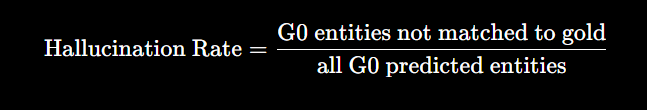

In [44]:
# ============================================================
# Reference-based entity hallucination rate
# ============================================================

domain_metrics_df["disease_hallucinated"] = (
    domain_metrics_df["g0_disease_count"]
    - domain_metrics_df["matched_disease_count"]
)

domain_metrics_df["chemical_hallucinated"] = (
    domain_metrics_df["g0_chemical_count"]
    - domain_metrics_df["matched_chemical_count"]
)

total_disease_hallucinated = domain_metrics_df["disease_hallucinated"].sum()
total_chemical_hallucinated = domain_metrics_df["chemical_hallucinated"].sum()

disease_hallucination_rate = (
    total_disease_hallucinated
    / domain_metrics_df["g0_disease_count"].sum()
)

chemical_hallucination_rate = (
    total_chemical_hallucinated
    / domain_metrics_df["g0_chemical_count"].sum()
)

print("=" * 70)
print("REFERENCE-BASED ENTITY HALLUCINATION RATE")
print("=" * 70)

print(f"\nDisease hallucinated: {total_disease_hallucinated}")
print(f"Disease hallucination rate: {disease_hallucination_rate:.4f}")
print(f"Disease hallucination rate (%): {disease_hallucination_rate * 100:.2f}%")

print(f"\nChemical hallucinated: {total_chemical_hallucinated}")
print(f"Chemical hallucination rate: {chemical_hallucination_rate:.4f}")
print(f"Chemical hallucination rate (%): {chemical_hallucination_rate * 100:.2f}%")

REFERENCE-BASED ENTITY HALLUCINATION RATE

Disease hallucinated: 2516
Disease hallucination rate: 0.8345
Disease hallucination rate (%): 83.45%

Chemical hallucinated: 399
Chemical hallucination rate: 0.8244
Chemical hallucination rate (%): 82.44%


In [45]:
# ============================================================
# Entity frequency
# ============================================================

avg_gold_disease = domain_metrics_df["gold_disease_count"].mean()
avg_g0_disease = domain_metrics_df["g0_disease_count"].mean()

avg_gold_chemical = domain_metrics_df["gold_chemical_count"].mean()
avg_g0_chemical = domain_metrics_df["g0_chemical_count"].mean()

print("=" * 70)
print("ENTITY FREQUENCY")
print("=" * 70)

print("\nDisease entities per answer:")
print(f"Gold average: {avg_gold_disease:.4f}")
print(f"G0 average:   {avg_g0_disease:.4f}")

print("\nChemical entities per answer:")
print(f"Gold average: {avg_gold_chemical:.4f}")
print(f"G0 average:   {avg_g0_chemical:.4f}")

ENTITY FREQUENCY

Disease entities per answer:
Gold average: 1.1740
G0 average:   3.0150

Chemical entities per answer:
Gold average: 0.2110
G0 average:   0.4840


# domain-specific NER evaluation is complete

| Metric                        | Disease | Chemical |
| ----------------------------- | ------: | -------: |
| Gold entities                 |   1,174 |      211 |
| G0 predicted                  |   3,015 |      484 |
| Matched                       |     499 |       85 |
| Retention / recall            |  42.50% |   40.28% |
| Precision                     |  16.55% |   17.56% |
| Micro F1                      |  23.82% |   24.46% |
| Reference-based mismatch rate |  83.45% |   82.44% |
| Avg. entities / answer        |   1.174 |    0.211 |
| G0 avg. entities / answer     |   3.015 |    0.484 |


In [46]:
# ============================================================
# Build final domain-evaluation dataframe
# ============================================================

final_domain_df = g0_eval_df.copy()

# Add domain metrics
final_domain_df = final_domain_df.merge(
    domain_metrics_df,
    on="pubid",
    how="left"
)

print("Final evaluation rows:", len(final_domain_df))
print("Columns:")
print(final_domain_df.columns.tolist())

display(final_domain_df.head(3))

Final evaluation rows: 1000
Columns:
['pubid', 'question', 'context', 'gold_answer', 'g0_answer', 'gold_disease_count', 'g0_disease_count', 'matched_disease_count', 'disease_retention', 'disease_precision', 'disease_recall', 'disease_f1', 'gold_chemical_count', 'g0_chemical_count', 'matched_chemical_count', 'chemical_retention', 'chemical_precision', 'chemical_recall', 'chemical_f1', 'disease_hallucinated', 'chemical_hallucinated']


,pubid,question,context,gold_answer,g0_answer,gold_disease_count,g0_disease_count,matched_disease_count,disease_retention,disease_precision,...,disease_f1,gold_chemical_count,g0_chemical_count,matched_chemical_count,chemical_retention,chemical_precision,chemical_recall,chemical_f1,disease_hallucinated,chemical_hallucinated
0,21645374,Do mitochondria play a role in remodelling lac...,{'contexts': ['Programmed cell death (PCD) is ...,Results depicted mitochondrial dynamics in viv...,Mitochondria have long been known as important...,0,0,0,NaN,NaN,...,NaN,1,0,0,0.0,NaN,0.0,NaN,0,0
1,16418930,Landolt C and snellen e acuity: differences in...,{'contexts': ['Assessment of visual acuity dep...,"Using the charts described, there was only a s...",with only small differences between LR and SE....,1,0,0,0.0,NaN,...,NaN,0,0,0,NaN,NaN,NaN,NaN,0,0
2,9488747,"Syncope during bathing in infants, a pediatric...",{'contexts': ['Apparent life-threatening event...,"""Aquagenic maladies"" could be a pediatric form...",: seizure or gastroesophageal reflux but this ...,2,12,0,0.0,0.0,...,NaN,0,1,0,NaN,0.0,NaN,NaN,12,1


In [47]:
# Save complete per-sample domain evaluation

domain_csv_path = "/content/g0_domain_evaluation.csv"

final_domain_df.to_csv(
    domain_csv_path,
    index=False
)

print("Saved:", domain_csv_path)

Saved: /content/g0_domain_evaluation.csv


In [48]:
# ============================================================
# Overall summary table
# ============================================================

summary_df = pd.DataFrame({
    "metric": [
        "Disease gold entities",
        "Disease G0 predicted entities",
        "Disease matched entities",
        "Disease retention",
        "Disease precision",
        "Disease micro recall",
        "Disease micro F1",
        "Disease reference-mismatch rate",
        "Gold disease entities per answer",
        "G0 disease entities per answer",
        "Chemical gold entities",
        "Chemical G0 predicted entities",
        "Chemical matched entities",
        "Chemical retention",
        "Chemical precision",
        "Chemical micro recall",
        "Chemical micro F1",
        "Chemical reference-mismatch rate",
        "Gold chemical entities per answer",
        "G0 chemical entities per answer"
    ],
    "value": [
        disease_micro["gold"],
        disease_micro["predicted"],
        disease_micro["matched"],
        disease_micro["recall"],
        disease_micro["precision"],
        disease_micro["recall"],
        disease_micro["f1"],
        disease_hallucination_rate,
        avg_gold_disease,
        avg_g0_disease,
        chemical_micro["gold"],
        chemical_micro["predicted"],
        chemical_micro["matched"],
        chemical_micro["recall"],
        chemical_micro["precision"],
        chemical_micro["recall"],
        chemical_micro["f1"],
        chemical_hallucination_rate,
        avg_gold_chemical,
        avg_g0_chemical
    ]
})

summary_path = "/content/g0_domain_summary.csv"

summary_df.to_csv(
    summary_path,
    index=False
)

print("Summary saved:", summary_path)

display(summary_df)

Summary saved: /content/g0_domain_summary.csv


,metric,value
0,Disease gold entities,1174.000000
1,Disease G0 predicted entities,3015.000000
2,Disease matched entities,499.000000
3,Disease retention,0.425043
4,Disease precision,0.165506
5,Disease micro recall,0.425043
6,Disease micro F1,0.238243
7,Disease reference-mismatch rate,0.834494
8,Gold disease entities per answer,1.174000
9,G0 disease entities per answer,3.015000


In [49]:
import shutil

shutil.copy(
    domain_csv_path,
    "/content/drive/MyDrive/g0_domain_evaluation.csv"
)

shutil.copy(
    summary_path,
    "/content/drive/MyDrive/g0_domain_summary.csv"
)

print("Both files copied to Google Drive.")

Both files copied to Google Drive.


In [10]:
!pip install -U "bitsandbytes>=0.46.1"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.1/43.1 MB 15.0 MB/s eta 0:00:00


In [1]:
import bitsandbytes as bnb

print("bitsandbytes version:", bnb.__version__)

bitsandbytes version: 0.50.2


# model/behavioral evaluation

In [50]:
# ============================================================
# MODEL / BEHAVIORAL EVALUATION
# Step 1: Answer length and repetition rate
# ============================================================

import re
import numpy as np
import pandas as pd


def word_count(text):
    """Count whitespace-separated words."""
    if not isinstance(text, str) or not text.strip():
        return 0

    return len(text.split())


def token_count(text):
    """Count tokens using the Qwen tokenizer."""
    if not isinstance(text, str) or not text.strip():
        return 0

    token_ids = tokenizer(
        text,
        add_special_tokens=False
    )["input_ids"]

    return len(token_ids)


def repetition_rate(text, n=3):
    """
    3-gram repetition rate.

    0.0 = no repeated n-grams
    Higher values = more repetition
    """

    if not isinstance(text, str) or not text.strip():
        return 0.0

    # Simple word-level tokens
    words = re.findall(r"\b\w+\b", text.lower())

    if len(words) < n:
        return 0.0

    ngrams = [
        tuple(words[i:i+n])
        for i in range(len(words) - n + 1)
    ]

    total_ngrams = len(ngrams)
    unique_ngrams = len(set(ngrams))

    return 1.0 - (unique_ngrams / total_ngrams)


# ------------------------------------------------------------
# Calculate behavioral features
# ------------------------------------------------------------

behavioral_df = g0_eval_df[[
    "pubid",
    "gold_answer",
    "g0_answer"
]].copy()


print("Calculating Gold answer statistics...")

behavioral_df["gold_word_count"] = (
    behavioral_df["gold_answer"]
    .apply(word_count)
)

behavioral_df["gold_token_count"] = (
    behavioral_df["gold_answer"]
    .apply(token_count)
)

behavioral_df["gold_repetition_rate"] = (
    behavioral_df["gold_answer"]
    .apply(repetition_rate)
)


print("Calculating G0 answer statistics...")

behavioral_df["g0_word_count"] = (
    behavioral_df["g0_answer"]
    .apply(word_count)
)

behavioral_df["g0_token_count"] = (
    behavioral_df["g0_answer"]
    .apply(token_count)
)

behavioral_df["g0_repetition_rate"] = (
    behavioral_df["g0_answer"]
    .apply(repetition_rate)
)


print("\nBehavioral features calculated!")
print("Rows:", len(behavioral_df))

Calculating Gold answer statistics...
Calculating G0 answer statistics...

Behavioral features calculated!
Rows: 1000


In [51]:
# ============================================================
# Overall answer length and repetition results
# ============================================================

print("=" * 70)
print("ANSWER LENGTH")
print("=" * 70)

print("\nGold:")
print(
    f"Average words: "
    f"{behavioral_df['gold_word_count'].mean():.2f}"
)

print(
    f"Average tokens: "
    f"{behavioral_df['gold_token_count'].mean():.2f}"
)

print("\nG0:")
print(
    f"Average words: "
    f"{behavioral_df['g0_word_count'].mean():.2f}"
)

print(
    f"Average tokens: "
    f"{behavioral_df['g0_token_count'].mean():.2f}"
)


print("\n" + "=" * 70)
print("REPETITION RATE")
print("=" * 70)

print("\nGold:")
print(
    f"Average 3-gram repetition rate: "
    f"{behavioral_df['gold_repetition_rate'].mean():.4f}"
)

print("\nG0:")
print(
    f"Average 3-gram repetition rate: "
    f"{behavioral_df['g0_repetition_rate'].mean():.4f}"
)

ANSWER LENGTH

Gold:
Average words: 39.66
Average tokens: 50.52

G0:
Average words: 154.28
Average tokens: 204.37

REPETITION RATE

Gold:
Average 3-gram repetition rate: 0.0086

G0:
Average 3-gram repetition rate: 0.0118


In [52]:
# ============================================================
# Relative behavioral changes: G0 vs Gold
# ============================================================

gold_avg_tokens = behavioral_df["gold_token_count"].mean()
g0_avg_tokens = behavioral_df["g0_token_count"].mean()

gold_avg_words = behavioral_df["gold_word_count"].mean()
g0_avg_words = behavioral_df["g0_word_count"].mean()

gold_avg_rep = behavioral_df["gold_repetition_rate"].mean()
g0_avg_rep = behavioral_df["g0_repetition_rate"].mean()


token_change_pct = (
    (g0_avg_tokens - gold_avg_tokens)
    / gold_avg_tokens * 100
)

word_change_pct = (
    (g0_avg_words - gold_avg_words)
    / gold_avg_words * 100
)

rep_change_pct = (
    (g0_avg_rep - gold_avg_rep)
    / gold_avg_rep * 100
    if gold_avg_rep > 0
    else np.nan
)


print("=" * 70)
print("G0 vs GOLD CHANGE")
print("=" * 70)

print(f"Token length change: {token_change_pct:.2f}%")
print(f"Word length change: {word_change_pct:.2f}%")
print(f"3-gram repetition change: {rep_change_pct:.2f}%")

G0 vs GOLD CHANGE
Token length change: 304.52%
Word length change: 289.02%
3-gram repetition change: 38.02%


In [53]:
# ============================================================
# Perplexity evaluation
# Step 1: Load fixed Base Qwen evaluator
# ============================================================

import torch
from transformers import AutoTokenizer, AutoModelForCausalLM

EVAL_MODEL_NAME = "Qwen/Qwen2.5-0.5B"

eval_tokenizer = AutoTokenizer.from_pretrained(
    EVAL_MODEL_NAME
)

eval_tokenizer.padding_side = "left"

if eval_tokenizer.pad_token is None:
    eval_tokenizer.pad_token = eval_tokenizer.eos_token

eval_model = AutoModelForCausalLM.from_pretrained(
    EVAL_MODEL_NAME,
    torch_dtype=torch.float16,
    device_map="auto"
)

eval_model.eval()

print("Fixed evaluator loaded!")
print("Model:", EVAL_MODEL_NAME)
print("Device:", eval_model.device)
print("Padding side:", eval_tokenizer.padding_side)

tokenizer_config.json:   0%|          | 0.00/7.23k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/1.67M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/7.03M [00:00<?, ?B/s]

[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

Fixed evaluator loaded!
Model: Qwen/Qwen2.5-0.5B
Device: cuda:0
Padding side: left


In [55]:
def calculate_batch_perplexity(rows, answer_column):
    """
    Calculate answer-only perplexity for a batch.
    Prompt tokens are masked with -100.
    """

    input_id_lists = []
    label_id_lists = []

    for row in rows:

        prompt = build_prompt(row)
        answer = str(row[answer_column])

        prompt_ids = eval_tokenizer(
            prompt,
            add_special_tokens=False,
            truncation=True,
            max_length=1024
        )["input_ids"]

        answer_ids = eval_tokenizer(
            answer,
            add_special_tokens=False
        )["input_ids"]

        input_ids = prompt_ids + answer_ids

        labels = (
            [-100] * len(prompt_ids)
            + answer_ids
        )

        input_id_lists.append(input_ids)
        label_id_lists.append(labels)

    # Pad input IDs
    batch = eval_tokenizer.pad(
        [{"input_ids": ids} for ids in input_id_lists],
        padding=True,
        return_tensors="pt"
    )

    input_ids = batch["input_ids"].to(eval_model.device)
    attention_mask = batch["attention_mask"].to(eval_model.device)

    # Create padded labels
    max_len = input_ids.shape[1]

    labels = torch.full(
        (len(label_id_lists), max_len),
        -100,
        dtype=torch.long
    )

    for i, label_ids in enumerate(label_id_lists):

        pad_length = max_len - len(label_ids)

        labels[i, pad_length:] = torch.tensor(
            label_ids,
            dtype=torch.long
        )

    # IMPORTANT: move labels to GPU
    labels = labels.to(eval_model.device)

    # Forward pass
    with torch.no_grad():

        outputs = eval_model(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        logits = outputs.logits

    # Shift for causal LM
    shift_logits = logits[:, :-1, :].contiguous()
    shift_labels = labels[:, 1:].contiguous()

    # Token-level loss
    loss_per_token = F.cross_entropy(
        shift_logits.view(-1, shift_logits.size(-1)),
        shift_labels.view(-1),
        reduction="none",
        ignore_index=-100
    ).view(shift_labels.shape)

    # Per-example perplexity
    perplexities = []

    for i in range(len(rows)):

        valid_tokens = shift_labels[i] != -100

        if valid_tokens.sum() == 0:
            perplexities.append(float("nan"))
            continue

        mean_loss = (
            loss_per_token[i][valid_tokens].mean().item()
        )

        perplexities.append(math.exp(mean_loss))

    return perplexities

In [56]:
test_rows = [
    g0_eval_df.iloc[i].to_dict()
    for i in range(4)
]

gold_test_ppl = calculate_batch_perplexity(
    test_rows,
    "gold_answer"
)

g0_test_ppl = calculate_batch_perplexity(
    test_rows,
    "g0_answer"
)

print("Gold test perplexities:")
print(gold_test_ppl)

print("\nG0 test perplexities:")
print(g0_test_ppl)

Gold test perplexities:
[9.71273100782147, 6.44484927647148, 7.338717225977015, 11.244980766441616]

G0 test perplexities:
[4.587969263865388, 4.985059367148202, 2.593802640698535, 4.530091724391524]


In [57]:
# ============================================================
# Full conditional perplexity evaluation
# 1,000 Gold + 1,000 G0 answers
# ============================================================

from tqdm.auto import tqdm
import numpy as np
import pandas as pd

PPL_BATCH_SIZE = 4

gold_perplexities = []
g0_perplexities = []

rows = [
    g0_eval_df.iloc[i].to_dict()
    for i in range(len(g0_eval_df))
]

print("Calculating Gold perplexity...")

for start in tqdm(
    range(0, len(rows), PPL_BATCH_SIZE),
    desc="Gold perplexity"
):
    batch_rows = rows[start:start + PPL_BATCH_SIZE]

    batch_ppl = calculate_batch_perplexity(
        batch_rows,
        "gold_answer"
    )

    gold_perplexities.extend(batch_ppl)


print("\nCalculating G0 perplexity...")

for start in tqdm(
    range(0, len(rows), PPL_BATCH_SIZE),
    desc="G0 perplexity"
):
    batch_rows = rows[start:start + PPL_BATCH_SIZE]

    batch_ppl = calculate_batch_perplexity(
        batch_rows,
        "g0_answer"
    )

    g0_perplexities.extend(batch_ppl)


print("\nPerplexity evaluation complete!")
print("Gold perplexities:", len(gold_perplexities))
print("G0 perplexities:", len(g0_perplexities))

Calculating Gold perplexity...


Gold perplexity:   0%|          | 0/250 [00:00<?, ?it/s]


Calculating G0 perplexity...


G0 perplexity:   0%|          | 0/250 [00:00<?, ?it/s]


Perplexity evaluation complete!
Gold perplexities: 1000
G0 perplexities: 1000


In [58]:
# ============================================================
# Perplexity summary
# ============================================================

behavioral_df["gold_perplexity"] = gold_perplexities
behavioral_df["g0_perplexity"] = g0_perplexities

gold_ppl_mean = np.nanmean(gold_perplexities)
g0_ppl_mean = np.nanmean(g0_perplexities)

gold_ppl_median = np.nanmedian(gold_perplexities)
g0_ppl_median = np.nanmedian(g0_perplexities)

print("=" * 70)
print("PERPLEXITY RESULTS")
print("=" * 70)

print("\nGold:")
print(f"Mean perplexity:   {gold_ppl_mean:.4f}")
print(f"Median perplexity: {gold_ppl_median:.4f}")

print("\nG0:")
print(f"Mean perplexity:   {g0_ppl_mean:.4f}")
print(f"Median perplexity: {g0_ppl_median:.4f}")

PERPLEXITY RESULTS

Gold:
Mean perplexity:   11.0743
Median perplexity: 9.2499

G0:
Mean perplexity:   3.5618
Median perplexity: 3.0998


In [59]:
# Relative perplexity change

ppl_change_pct = (
    (g0_ppl_mean - gold_ppl_mean)
    / gold_ppl_mean * 100
)

print(f"G0 vs Gold perplexity change: {ppl_change_pct:.2f}%")

G0 vs Gold perplexity change: -67.84%


In [60]:
# ============================================================
# FINAL PER-SAMPLE EVALUATION DATASET
# Domain + Behavioral Metrics
# ============================================================

# Keep the useful behavioral columns
behavioral_results = behavioral_df[[
    "pubid",
    "gold_word_count",
    "gold_token_count",
    "gold_repetition_rate",
    "g0_word_count",
    "g0_token_count",
    "g0_repetition_rate",
    "gold_perplexity",
    "g0_perplexity"
]].copy()

# Keep the domain columns
domain_results = domain_metrics_df.copy()

# Merge domain + behavioral results
final_evaluation_df = domain_results.merge(
    behavioral_results,
    on="pubid",
    how="left"
)

print("Final evaluation rows:", len(final_evaluation_df))
print("Final evaluation columns:", len(final_evaluation_df.columns))

display(final_evaluation_df.head(3))

Final evaluation rows: 1000
Final evaluation columns: 25


,pubid,gold_disease_count,g0_disease_count,matched_disease_count,disease_retention,disease_precision,disease_recall,disease_f1,gold_chemical_count,g0_chemical_count,...,disease_hallucinated,chemical_hallucinated,gold_word_count,gold_token_count,gold_repetition_rate,g0_word_count,g0_token_count,g0_repetition_rate,gold_perplexity,g0_perplexity
0,21645374,0,0,0,NaN,NaN,NaN,NaN,1,0,...,0,0,97,124,0.021053,89,119,0.0,9.712731,4.587969
1,16418930,1,0,0,0.0,NaN,0.0,NaN,0,0,...,0,0,38,53,0.000000,90,105,0.0,6.444849,4.985059
2,9488747,2,12,0,0.0,0.0,0.0,NaN,0,1,...,12,1,11,21,0.000000,196,258,0.0,7.338717,2.593803


In [61]:
# Save final per-sample evaluation

final_evaluation_path = "/content/g0_final_evaluation.csv"

final_evaluation_df.to_csv(
    final_evaluation_path,
    index=False
)

print("Saved:", final_evaluation_path)

Saved: /content/g0_final_evaluation.csv


In [62]:
# ============================================================
# FINAL OVERALL SUMMARY
# ============================================================

final_summary = pd.DataFrame({
    "metric": [
        "Disease retention",
        "Disease precision",
        "Disease micro recall",
        "Disease micro F1",
        "Disease reference-mismatch rate",

        "Chemical retention",
        "Chemical precision",
        "Chemical micro recall",
        "Chemical micro F1",
        "Chemical reference-mismatch rate",

        "Gold disease entities per answer",
        "G0 disease entities per answer",
        "Gold chemical entities per answer",
        "G0 chemical entities per answer",

        "Gold average words",
        "G0 average words",
        "Gold average tokens",
        "G0 average tokens",

        "Gold 3-gram repetition rate",
        "G0 3-gram repetition rate",

        "Gold mean perplexity",
        "G0 mean perplexity",
        "Gold median perplexity",
        "G0 median perplexity"
    ],

    "value": [
        disease_micro["recall"],
        disease_micro["precision"],
        disease_micro["recall"],
        disease_micro["f1"],
        disease_hallucination_rate,

        chemical_micro["recall"],
        chemical_micro["precision"],
        chemical_micro["recall"],
        chemical_micro["f1"],
        chemical_hallucination_rate,

        avg_gold_disease,
        avg_g0_disease,
        avg_gold_chemical,
        avg_g0_chemical,

        behavioral_df["gold_word_count"].mean(),
        behavioral_df["g0_word_count"].mean(),
        behavioral_df["gold_token_count"].mean(),
        behavioral_df["g0_token_count"].mean(),

        behavioral_df["gold_repetition_rate"].mean(),
        behavioral_df["g0_repetition_rate"].mean(),

        behavioral_df["gold_perplexity"].mean(),
        behavioral_df["g0_perplexity"].mean(),
        behavioral_df["gold_perplexity"].median(),
        behavioral_df["g0_perplexity"].median()
    ]
})

summary_path = "/content/g0_final_summary.csv"

final_summary.to_csv(
    summary_path,
    index=False
)

display(final_summary)

print("\nSaved:", summary_path)

,metric,value
0,Disease retention,0.425043
1,Disease precision,0.165506
2,Disease micro recall,0.425043
3,Disease micro F1,0.238243
4,Disease reference-mismatch rate,0.834494
5,Chemical retention,0.402844
6,Chemical precision,0.175620
7,Chemical micro recall,0.402844
8,Chemical micro F1,0.244604
9,Chemical reference-mismatch rate,0.824380



Saved: /content/g0_final_summary.csv


In [63]:
import shutil

shutil.copy(
    "/content/g0_final_evaluation.csv",
    "/content/drive/MyDrive/g0_final_evaluation.csv"
)

shutil.copy(
    "/content/g0_final_summary.csv",
    "/content/drive/MyDrive/g0_final_summary.csv"
)

print("Final evaluation files saved to Google Drive.")

Final evaluation files saved to Google Drive.


# REUSABLE GENERATION EVALUATOR

In [65]:
# ============================================================
# REUSABLE GENERATION EVALUATOR
# Works for G0 / G1 / G2
# ============================================================

from tqdm.auto import tqdm
import numpy as np
import pandas as pd


def evaluate_generation(
    eval_df,
    prediction_column,
    generation_name,
    gold_entities=gold_entities_clean
):
    """
    Evaluate one generation (G0, G1, G2, ...).

    Required eval_df columns:
        pubid
        question
        context
        gold_answer
        prediction_column
    """

    print("=" * 70)
    print(f"EVALUATING {generation_name}")
    print("=" * 70)

    texts = (
        eval_df[prediction_column]
        .fillna("")
        .astype(str)
        .tolist()
    )

    gold_texts = (
        eval_df["gold_answer"]
        .fillna("")
        .astype(str)
        .tolist()
    )

    # --------------------------------------------------------
    # A. NER
    # --------------------------------------------------------

    print("\n[1/4] Running PubMedBERT NER...")

    prediction_raw = []

    NER_BATCH_SIZE = 8

    for start in tqdm(
        range(0, len(texts), NER_BATCH_SIZE),
        desc=f"{generation_name} NER"
    ):

        batch = texts[start:start + NER_BATCH_SIZE]

        batch_predictions = pubmed_ner_pipeline(
            batch,
            batch_size=NER_BATCH_SIZE
        )

        prediction_raw.extend(batch_predictions)

    print("NER prediction sets:", len(prediction_raw))

    # Merge B/I entities
    prediction_entities = []

    for text, predictions in tqdm(
        zip(texts, prediction_raw),
        total=len(texts),
        desc=f"{generation_name} entity processing"
    ):

        entities = merge_pubmed_predictions(
            text,
            predictions
        )

        entities = deduplicate_entities(entities)

        prediction_entities.append(entities)

    # --------------------------------------------------------
    # B. Domain-specific metrics
    # --------------------------------------------------------

    print("\n[2/4] Calculating domain metrics...")

    domain_rows = []

    for i in range(len(eval_df)):

        gold_entities_i = gold_entities[i]
        pred_entities_i = prediction_entities[i]

        disease_metrics = calculate_sample_metrics(
            gold_entities_i,
            pred_entities_i,
            "Disease"
        )

        chemical_metrics = calculate_sample_metrics(
            gold_entities_i,
            pred_entities_i,
            "Chemical"
        )

        domain_rows.append({
            "pubid": eval_df.iloc[i]["pubid"],

            "gold_disease_count":
                disease_metrics["gold_count"],

            f"{generation_name.lower()}_disease_count":
                disease_metrics["pred_count"],

            f"{generation_name.lower()}_matched_disease_count":
                disease_metrics["matched_count"],

            f"{generation_name.lower()}_disease_retention":
                disease_metrics["retention"],

            f"{generation_name.lower()}_disease_precision":
                disease_metrics["precision"],

            f"{generation_name.lower()}_disease_recall":
                disease_metrics["recall"],

            f"{generation_name.lower()}_disease_f1":
                disease_metrics["f1"],

            "gold_chemical_count":
                chemical_metrics["gold_count"],

            f"{generation_name.lower()}_chemical_count":
                chemical_metrics["pred_count"],

            f"{generation_name.lower()}_matched_chemical_count":
                chemical_metrics["matched_count"],

            f"{generation_name.lower()}_chemical_retention":
                chemical_metrics["retention"],

            f"{generation_name.lower()}_chemical_precision":
                chemical_metrics["precision"],

            f"{generation_name.lower()}_chemical_recall":
                chemical_metrics["recall"],

            f"{generation_name.lower()}_chemical_f1":
                chemical_metrics["f1"],
        })

    domain_results = pd.DataFrame(domain_rows)

    # Reference-based mismatch/hallucination proxy
    short_name = generation_name.lower()

    domain_results[
        f"{short_name}_disease_hallucinated"
    ] = (
        domain_results[f"{short_name}_disease_count"]
        - domain_results[f"{short_name}_matched_disease_count"]
    )

    domain_results[
        f"{short_name}_chemical_hallucinated"
    ] = (
        domain_results[f"{short_name}_chemical_count"]
        - domain_results[f"{short_name}_matched_chemical_count"]
    )

    # --------------------------------------------------------
    # C. Behavioral metrics
    # --------------------------------------------------------

    print("\n[3/4] Calculating behavioral metrics...")

    behavioral_results = pd.DataFrame({
        "pubid": eval_df["pubid"],

        f"{short_name}_word_count":
            [word_count(x) for x in texts],

        f"{short_name}_token_count":
            [token_count(x) for x in texts],

        f"{short_name}_repetition_rate":
            [repetition_rate(x) for x in texts]
    })

    # --------------------------------------------------------
    # D. Perplexity
    # --------------------------------------------------------

    print("\n[4/4] Calculating perplexity...")

    prediction_rows = [
        eval_df.iloc[i].to_dict()
        for i in range(len(eval_df))
    ]

    perplexities = []

    PPL_BATCH_SIZE = 4

    for start in tqdm(
        range(0, len(prediction_rows), PPL_BATCH_SIZE),
        desc=f"{generation_name} perplexity"
    ):

        batch_rows = prediction_rows[
            start:start + PPL_BATCH_SIZE
        ]

        batch_ppl = calculate_batch_perplexity(
            batch_rows,
            prediction_column
        )

        perplexities.extend(batch_ppl)

    behavioral_results[
        f"{short_name}_perplexity"
    ] = perplexities

    # --------------------------------------------------------
    # Final per-sample dataframe
    # --------------------------------------------------------

    result_df = (
        domain_results
        .merge(
            behavioral_results,
            on="pubid",
            how="left"
        )
    )

    # Add original text
    result_df[f"{short_name}_answer"] = texts

    # --------------------------------------------------------
    # Overall summary
    # --------------------------------------------------------

    total_gold_disease = (
        result_df["gold_disease_count"].sum()
    )

    total_pred_disease = (
        result_df[f"{short_name}_disease_count"].sum()
    )

    total_matched_disease = (
        result_df[
            f"{short_name}_matched_disease_count"
        ].sum()
    )

    disease_precision = (
        total_matched_disease / total_pred_disease
        if total_pred_disease > 0
        else 0
    )

    disease_recall = (
        total_matched_disease / total_gold_disease
        if total_gold_disease > 0
        else 0
    )

    disease_f1 = (
        2 * disease_precision * disease_recall
        / (disease_precision + disease_recall)
        if disease_precision + disease_recall > 0
        else 0
    )

    total_gold_chemical = (
        result_df["gold_chemical_count"].sum()
    )

    total_pred_chemical = (
        result_df[f"{short_name}_chemical_count"].sum()
    )

    total_matched_chemical = (
        result_df[
            f"{short_name}_matched_chemical_count"
        ].sum()
    )

    chemical_precision = (
        total_matched_chemical / total_pred_chemical
        if total_pred_chemical > 0
        else 0
    )

    chemical_recall = (
        total_matched_chemical / total_gold_chemical
        if total_gold_chemical > 0
        else 0
    )

    chemical_f1 = (
        2 * chemical_precision * chemical_recall
        / (chemical_precision + chemical_recall)
        if chemical_precision + chemical_recall > 0
        else 0
    )

    disease_hallucination = (
        1 - disease_precision
        if total_pred_disease > 0
        else 0
    )

    chemical_hallucination = (
        1 - chemical_precision
        if total_pred_chemical > 0
        else 0
    )

    summary = {
        "generation": generation_name,

        "disease_retention":
            disease_recall,

        "disease_precision":
            disease_precision,

        "disease_recall":
            disease_recall,

        "disease_f1":
            disease_f1,

        "disease_reference_mismatch_rate":
            disease_hallucination,

        "chemical_retention":
            chemical_recall,

        "chemical_precision":
            chemical_precision,

        "chemical_recall":
            chemical_recall,

        "chemical_f1":
            chemical_f1,

        "chemical_reference_mismatch_rate":
            chemical_hallucination,

        "avg_word_count":
            np.mean(
                result_df[f"{short_name}_word_count"]
            ),

        "avg_token_count":
            np.mean(
                result_df[f"{short_name}_token_count"]
            ),

        "avg_repetition_rate":
            np.mean(
                result_df[f"{short_name}_repetition_rate"]
            ),

        "mean_perplexity":
            np.nanmean(
                result_df[f"{short_name}_perplexity"]
            ),

        "median_perplexity":
            np.nanmedian(
                result_df[f"{short_name}_perplexity"]
            )
    }

    summary_df = pd.DataFrame([summary])

    print("\nEvaluation complete!")

    return result_df, summary_df

In [66]:
g0_reusable_results, g0_reusable_summary = evaluate_generation(
    g0_eval_df,
    "g0_answer",
    "G0"
)

display(g0_reusable_summary)

EVALUATING G0

[1/4] Running PubMedBERT NER...


G0 NER:   0%|          | 0/125 [00:00<?, ?it/s]

NER prediction sets: 1000


G0 entity processing:   0%|          | 0/1000 [00:00<?, ?it/s]


[2/4] Calculating domain metrics...

[3/4] Calculating behavioral metrics...

[4/4] Calculating perplexity...


G0 perplexity:   0%|          | 0/250 [00:00<?, ?it/s]


Evaluation complete!


,generation,disease_retention,disease_precision,disease_recall,disease_f1,disease_reference_mismatch_rate,chemical_retention,chemical_precision,chemical_recall,chemical_f1,chemical_reference_mismatch_rate,avg_word_count,avg_token_count,avg_repetition_rate,mean_perplexity,median_perplexity
0,G0,0.425043,0.165506,0.425043,0.238243,0.834494,0.402844,0.17562,0.402844,0.244604,0.82438,154.284,204.37,0.011819,3.561765,3.099832
